# Caso de Negocio

El caso de negocio consiste en desarrollar un modelo predictivo que permita estimar si un cliente de una empresa de telecomunicaciones abandonará el servicio (churn) a partir de información disponible sobre sus características y los servicios que utiliza. Para ello se utilizará un dataset que incluye variables relacionadas con el perfil del cliente, su antigüedad en la empresa, los servicios contratados y las condiciones de facturación y pago. El objetivo es entrenar un modelo de machine learning capaz de predecir la variable objetivo “Churn”, identificando a los clientes con mayor probabilidad de cancelar el servicio. Esta información puede ser utilizada por la empresa para implementar estrategias de retención de manera anticipada, reduciendo la pérdida de clientes y mejorando la gestión de la relación con los usuarios.

# Obtención y descripción de dataset

Importamos todas las librerias necesarias para el TP1

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder

Leemos el csv para obtener el dataframe y comenzar el proyecto

In [2]:
df_churn = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_churn_backup = df_churn.copy()
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Pasamos todos los valores de las columnas a minúsculas para que esten todos de la misma forma.

In [3]:
df_churn.columns = df_churn.columns.str.lower()
df_churn.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Descripción del dataset

El dataset utilizado contiene información de clientes de una empresa de telecomunicaciones y tiene como objetivo analizar los factores asociados al abandono del servicio (churn).

Cada fila del dataset representa un cliente individual.

El objetivo del análisis es identificar patrones que permitan entender qué variables influyen en la probabilidad de que un cliente abandone el servicio y eventualmente desarrollar un modelo predictivo que permita anticipar ese comportamiento. Predecir si un cliente va "churnear".

En total, el dataset contiene **7043 clientes y 21 variables**.

Las variables pueden agruparse en cuatro grandes categorías:

1. Información del cliente
* género
* si es adulto mayor
* si tiene pareja
* si tiene dependientes

2. Información del servicio
* tipo de servicio telefónico
* servicio de internet
* servicios adicionales

3. Información contractual
* tipo de contrato
* método de pago
* facturación electrónica

4. Información económica
* cargo mensual
* cargos acumulados


## Dataset Dictionary

Diccionario de datos con la descripción de cada variable del dataset.

| Variable | Descripción | Valores posibles |
|--------|-------------|----------------|
| customerID | Identificador único del cliente | String |
| gender | Género del cliente | Male / Female |
| SeniorCitizen | Indica si el cliente es adulto mayor | 0 = No / 1 = Sí |
| Partner | Indica si el cliente tiene pareja | Yes / No |
| Dependents | Indica si el cliente tiene dependientes | Yes / No |
| tenure | Cantidad de meses que el cliente lleva en la empresa | Número entero |
| PhoneService | Indica si el cliente tiene servicio telefónico | Yes / No |
| MultipleLines | Indica si el cliente tiene múltiples líneas telefónicas | Yes / No / No phone service |
| InternetService | Tipo de servicio de internet contratado | DSL / Fiber optic / No |
| OnlineSecurity | Indica si el cliente tiene servicio de seguridad online | Yes / No / No internet service |
| OnlineBackup | Indica si el cliente tiene servicio de respaldo online | Yes / No / No internet service |
| DeviceProtection | Indica si el cliente tiene protección de dispositivos | Yes / No / No internet service |
| TechSupport | Indica si el cliente tiene soporte técnico | Yes / No / No internet service |
| StreamingTV | Indica si el cliente tiene servicio de TV por streaming | Yes / No / No internet service |
| StreamingMovies | Indica si el cliente tiene servicio de películas por streaming | Yes / No / No internet service |
| Contract | Tipo de contrato del cliente | Month-to-month / One year / Two year |
| PaperlessBilling | Indica si el cliente utiliza facturación electrónica | Yes / No |
| PaymentMethod | Método de pago del cliente | Electronic check / Mailed check / Bank transfer / Credit card |
| MonthlyCharges | Cargo mensual que paga el cliente | Número decimal |
| TotalCharges | Total pagado por el cliente desde que inició el servicio | Número decimal |
| Churn | Indica si el cliente abandonó el servicio | Yes / No |

# EDA

Verificamos los tipos de datos, las columnas, el uso en memoria, etc.

In [4]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [5]:
df_churn.describe()

,seniorcitizen,tenure,monthlycharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df_churn.shape

(7043, 21)

Verificamos la existencia de NAs, en este caso el dataset ya estaba limpio y nuestras variables no contienen Nas.

In [7]:
df_churn.isna().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


Verificamos la existencia de duplicados en el df_churn para decidir que hacer en caso de encontrarlos.

In [8]:
df_churn.duplicated().sum()

np.int64(0)

In [9]:
df_churn["totalcharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [10]:
df_churn[df_churn["totalcharges"]==" "].head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [11]:
df_churn["totalcharges"] = pd.to_numeric(df_churn["totalcharges"], errors="coerce")
df_churn[df_churn["totalcharges"]==" "]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


Para comenzar con el análisis exploratorio primero evidenciamos la proporción de churn que nos muestra que hay aproximadamente un 26,5% de clientes que churnean.

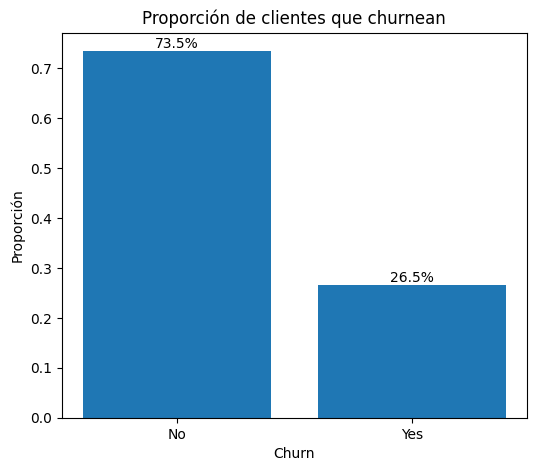

In [12]:
churn_prop = df_churn["churn"].value_counts(normalize=True)
plt.figure(figsize=(6,5))
bars = plt.bar(churn_prop.index, churn_prop.values)
plt.title("Proporción de clientes que churnean")
plt.xlabel("Churn")
plt.ylabel("Proporción")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.1%}", ha='center', va='bottom')

plt.show()

Los gráficos muestran que hay más o menos la misma cantidad de hombres y mujeres, así que el género no parece marcar mucha diferencia. La mayoría de los clientes no son senior citizens y tampoco tienen dependents, mientras que lo de partner está bastante parejo entre los que tienen pareja y los que no. En monthly charges se ve que los precios de los planes están bastante repartidos entre valores bajos y altos. Y en tenure aparecen muchos clientes muy nuevos y también muchos con bastante antigüedad, lo que sugiere que el tiempo que llevan con la empresa puede ser una variable importante para entender el churn.

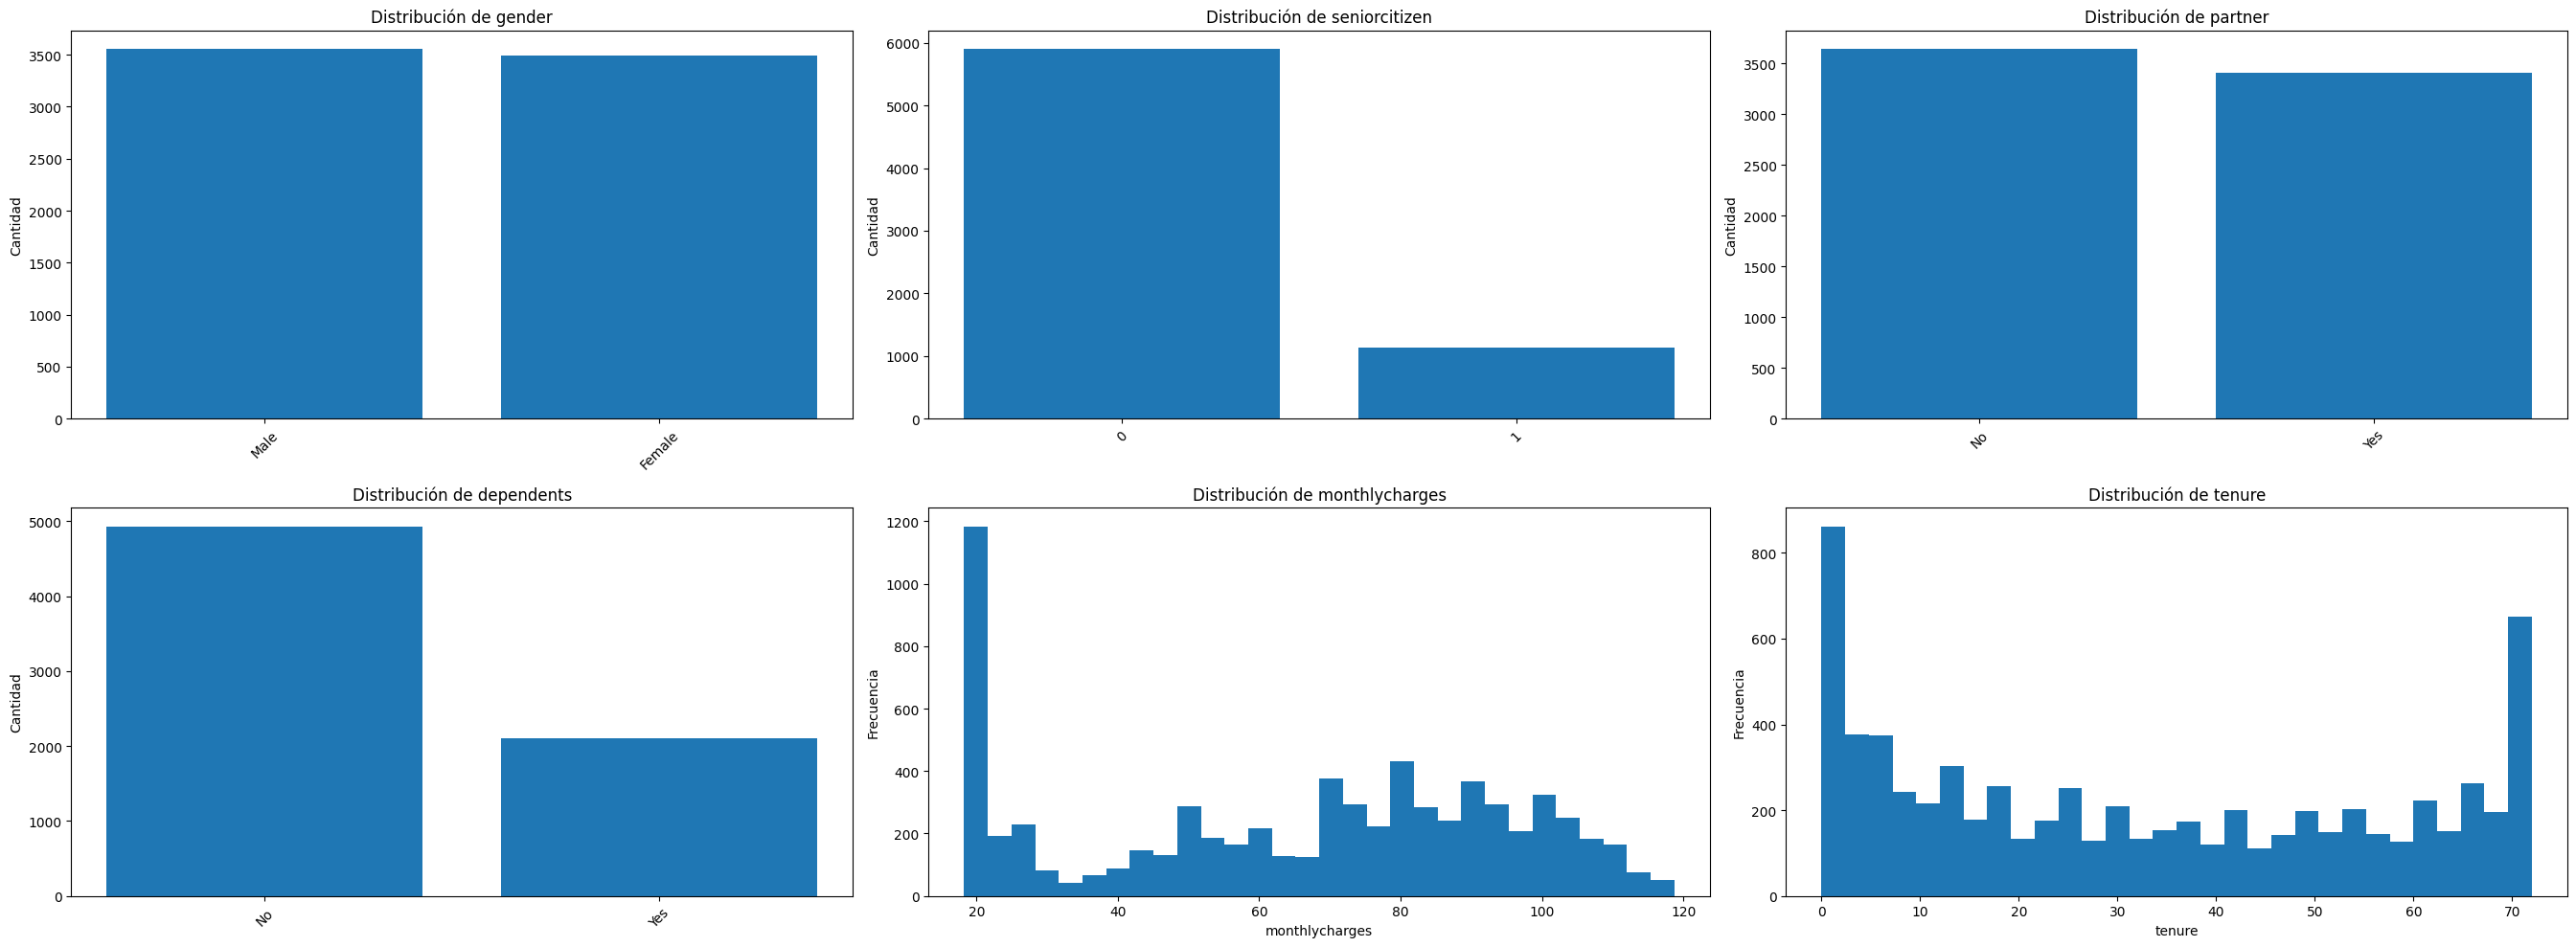

In [13]:
categorical = ["gender", "seniorcitizen", "partner", "dependents"]
numerical = ["monthlycharges", "tenure"]
plt.figure(figsize=(27,10))

for i, col in enumerate(categorical, 1):
    plt.subplot(2,3,i)
    counts = df_churn[col].value_counts()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribución de {col}")
    plt.ylabel("Cantidad")
    plt.xticks(rotation=45)

for i, col in enumerate(numerical, 5):
    plt.subplot(2,3,i)
    plt.hist(df_churn[col].dropna(), bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Los datos muestran que el churn es mucho más alto en clientes con contrato mes a mes, mientras que los contratos de uno o dos años casi no abandonan. También churnean más quienes pagan con electronic check, los que tienen fibra óptica y los que no tienen servicios extra como online security o tech support. En cambio, variables como género, phone service o multiple lines casi no muestran diferencias.

In [14]:
cols = ["contract","internetservice","paymentmethod","partner","paperlessbilling",
        "seniorcitizen","gender","dependents","phoneservice","onlinesecurity",
        "multiplelines","onlinebackup","deviceprotection","techsupport",
        "streamingtv","streamingmovies"]

for col in cols:
    counts = pd.crosstab(df_churn[col], df_churn["churn"])
    props = pd.crosstab(df_churn[col], df_churn["churn"], normalize="index").round(2)
    table = pd.concat([counts, props], axis=1, keys=["count","proportion"])
    print("\n", col)
    print(table)


 contract
               count       proportion      
churn             No   Yes         No   Yes
contract                                   
Month-to-month  2220  1655       0.57  0.43
One year        1307   166       0.89  0.11
Two year        1647    48       0.97  0.03

 internetservice
                count       proportion      
churn              No   Yes         No   Yes
internetservice                             
DSL              1962   459       0.81  0.19
Fiber optic      1799  1297       0.58  0.42
No               1413   113       0.93  0.07

 paymentmethod
                          count       proportion      
churn                        No   Yes         No   Yes
paymentmethod                                         
Bank transfer (automatic)  1286   258       0.83  0.17
Credit card (automatic)    1290   232       0.85  0.15
Electronic check           1294  1071       0.55  0.45
Mailed check               1304   308       0.81  0.19

 partner
        count       propor

Los gráficos confirman lo mismo que se veía en los números: el churn es mucho más alto en contratos mes a mes, mientras que casi desaparece en contratos largos. También es más alto en clientes con fibra óptica, en quienes pagan con electronic check y en los que usan paperless billing. Además, los senior citizens y los clientes sin tech support muestran una mayor proporción de abandono.

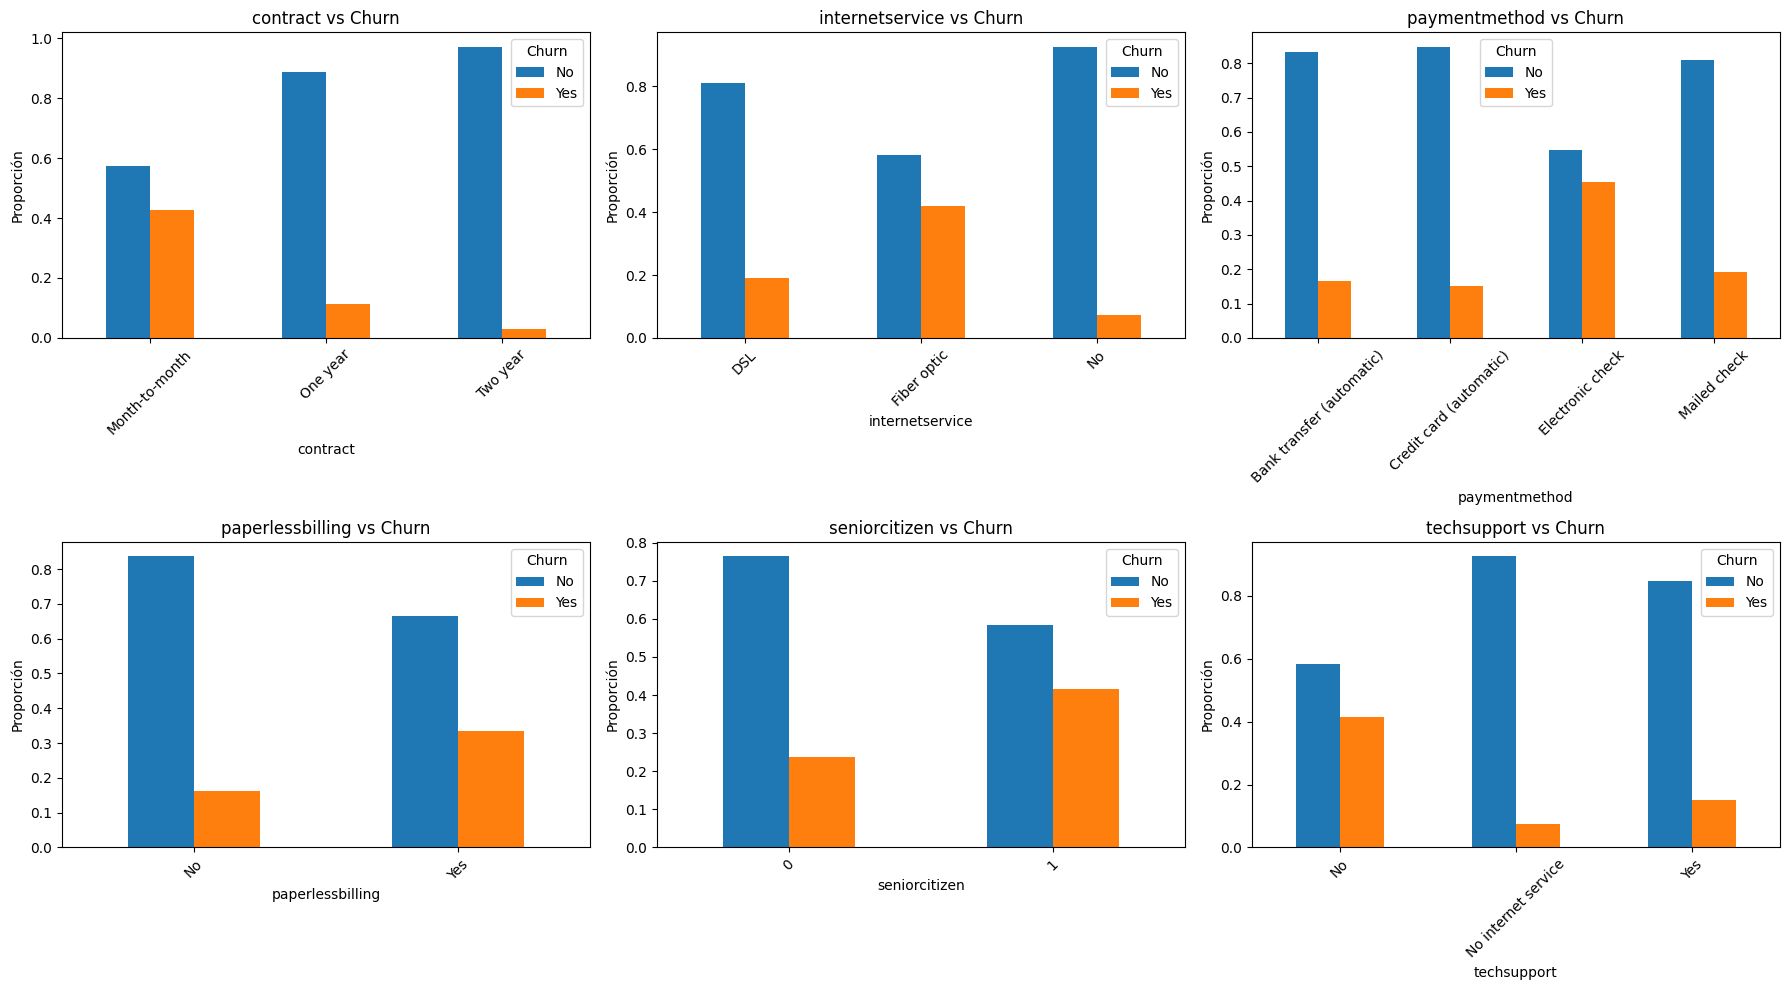

In [15]:
cols = ["contract","internetservice","paymentmethod",
        "paperlessbilling","seniorcitizen","techsupport"]
plt.figure(figsize=(18,10))
for i, col in enumerate(cols, 1):
    plt.subplot(2,3,i)
    table = pd.crosstab(df_churn[col], df_churn["churn"], normalize="index")
    table.plot(kind="bar", ax=plt.gca())
    plt.title(f"{col} vs Churn")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(title="Churn")

plt.tight_layout()
plt.show()

Acá se ve que el churn ocurre sobre todo en clientes con poca antigüedad: la mayoría de los que se van están en los primeros meses, mientras que los clientes con muchos años casi no abandonan. También se nota que quienes churnean tienden a tener monthly charges más altos, y que los clientes que se quedan acumulan total charges mucho mayores, lo que tiene sentido porque llevan más tiempo usando el servicio.

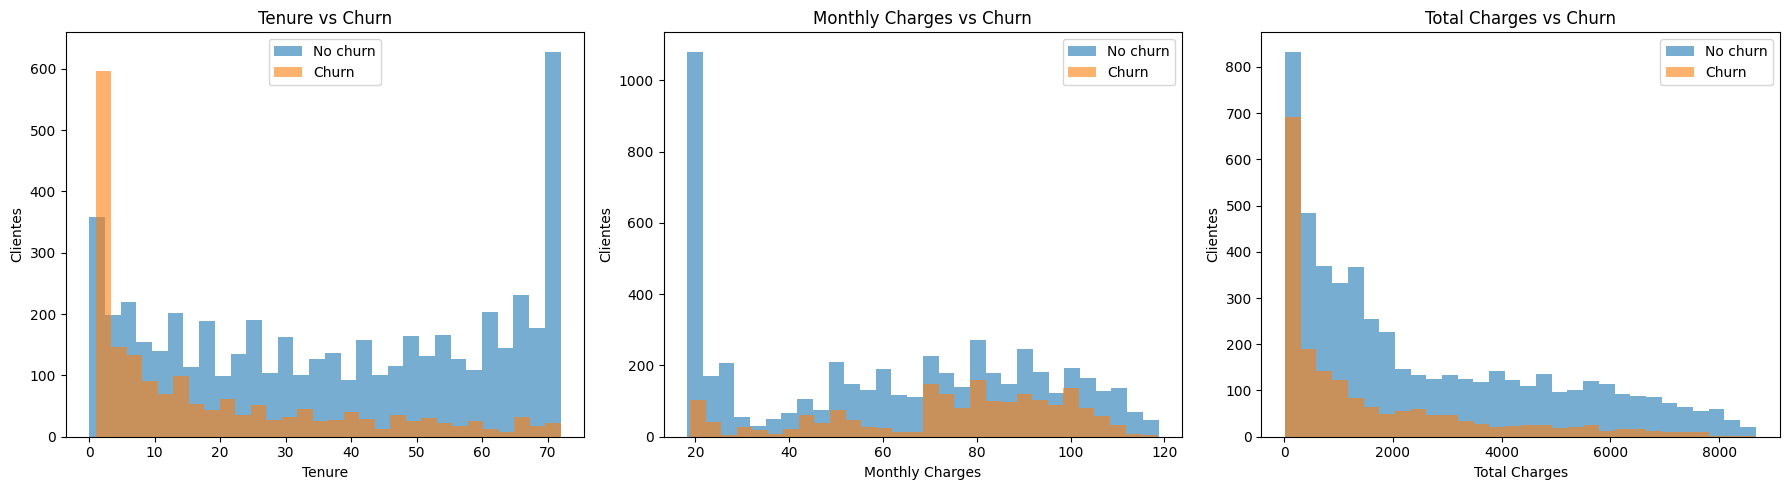

In [16]:
churn_yes = df_churn[df_churn["churn"] == "Yes"]
churn_no = df_churn[df_churn["churn"] == "No"]
plt.figure(figsize=(18,5))

# Tenure
plt.subplot(1,3,1)
plt.hist(churn_no["tenure"], bins=30, alpha=0.6, label="No churn")
plt.hist(churn_yes["tenure"], bins=30, alpha=0.6, label="Churn")
plt.title("Tenure vs Churn")
plt.xlabel("Tenure")
plt.ylabel("Clientes")
plt.legend()

# Monthly Charges
plt.subplot(1,3,2)
plt.hist(churn_no["monthlycharges"], bins=30, alpha=0.6, label="No churn")
plt.hist(churn_yes["monthlycharges"], bins=30, alpha=0.6, label="Churn")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Clientes")
plt.legend()

# Total Charges
plt.subplot(1,3,3)
plt.hist(churn_no["totalcharges"], bins=30, alpha=0.6, label="No churn")
plt.hist(churn_yes["totalcharges"], bins=30, alpha=0.6, label="Churn")
plt.title("Total Charges vs Churn")
plt.xlabel("Total Charges")
plt.ylabel("Clientes")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
def churn_count(x):
    plt.figure(figsize=(8,5))
    sns.countplot(x=x, hue="churn", data=df_churn)
    plt.title(f"{x} vs Churn")
    plt.show()

In [18]:
def churn_violin(y):
    sns.violinplot(x="churn", y=y, data=df_churn)
    plt.title(f"{y} by Churn")
    plt.show()

El gráfico muestra una relación negativa clara entre el tenure y la tasa de churn. A medida que aumenta la antigüedad del cliente, la probabilidad de abandono disminuye. La regresión lineal presenta un R² de 0.67, lo que indica una relación relativamente fuerte entre ambas variables y sugiere que el tiempo que un cliente lleva con la empresa es un factor importante para explicar el churn.

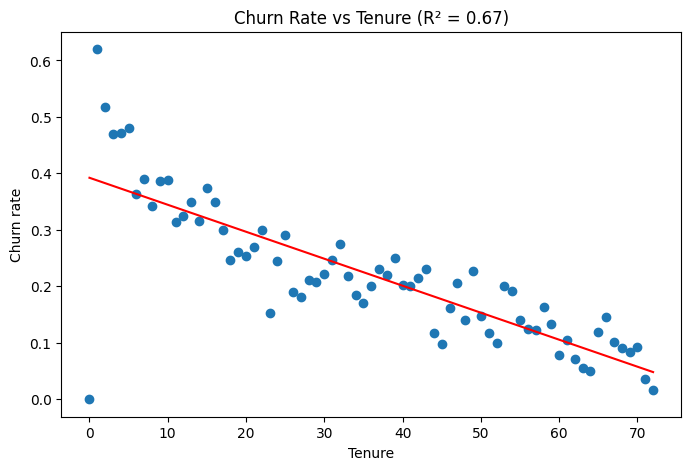

In [19]:
tenure_churn = (df_churn.assign(churn_num=(df_churn["churn"] == "Yes").astype(int)).groupby("tenure")["churn_num"].mean())
x = tenure_churn.index
y = tenure_churn.values
m, b = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0,1]
r2 = r**2
plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.plot(x, m*x + b, color="red")
plt.title(f"Churn Rate vs Tenure (R² = {r2:.2f})")
plt.xlabel("Tenure")
plt.ylabel("Churn rate")
plt.show()

El gráfico muestra que los clientes que churnean tienden a tener monthly charges más altos que aquellos que permanecen en la empresa. Esto sugiere que los clientes con servicios más costosos presentan una mayor probabilidad de abandono. Esto podría indicar que los clientes con planes más costosos son más sensibles al valor percibido del servicio y, por lo tanto, tienen mayor probabilidad de abandonar si no se cumplen sus expectativas.

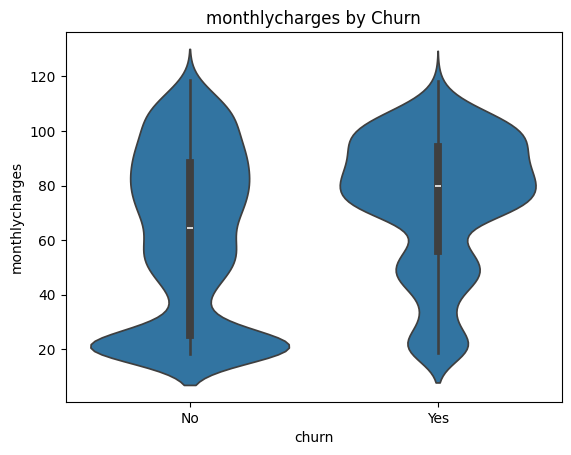

In [20]:
churn_violin("monthlycharges")

Transformamos las variables binarias para que sean 0/1 y poder realizar una correlación con el churn

In [21]:
binary_cols = [
    "partner",
    "dependents",
    "phoneservice",
    "paperlessbilling",
    "churn"
]

df_churn[binary_cols] = df_churn[binary_cols].replace({"Yes":1, "No":0})

/tmp/ipykernel_774/636317191.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_churn[binary_cols] = df_churn[binary_cols].replace({"Yes":1, "No":0})


El gráfico muestra que no hay correlaciones muy fuertes con el churn en estas variables. La relación más visible es una correlación positiva leve con paperless billing (0.19), lo que sugiere que quienes usan facturación digital abandonan un poco más. En cambio, tener partner (-0.15) o dependents (-0.16) está levemente asociado con menor churn (familias).

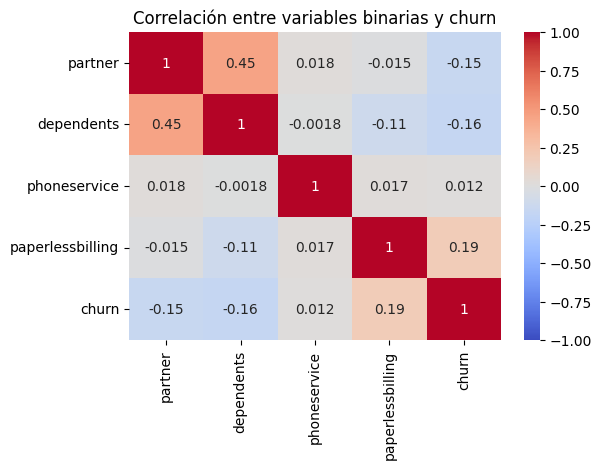

In [22]:
corr_matrix = df_churn[binary_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables binarias y churn")
plt.show()

## Insights del análisis exploratorio (REVISAR)

A partir del análisis exploratorio se identifican varios patrones asociados al churn de clientes:

- **Tenure (antigüedad del cliente):**
  - Existe una relación negativa clara entre el tenure y la tasa de churn.
  - Los clientes con menor antigüedad presentan una probabilidad mucho mayor de abandonar el servicio.
  - A medida que aumenta el tiempo del cliente en la empresa, la probabilidad de churn disminuye.
  - La regresión lineal muestra un **R² = 0.67**, lo que sugiere una relación relativamente fuerte entre ambas variables.

- **Monthly Charges (cargo mensual):**
  - Los clientes que realizan churn tienden a tener **monthly charges más altos** que aquellos que permanecen.
  - Esto sugiere que los clientes con servicios más costosos pueden tener mayor sensibilidad al valor percibido del servicio.

- **Tipo de contrato:**
  - El churn es **mucho más alto en contratos month-to-month**.
  - Los contratos de **uno y dos años presentan tasas de abandono considerablemente menores**.
  - Esto sugiere que los contratos más largos podrían funcionar como estrategia de retención de clientes.

- **Otras variables asociadas al churn:**
  - Mayor churn en clientes con **internet fiber optic**.
  - Mayor churn en quienes pagan mediante **electronic check**.
  - Mayor churn en clientes con **paperless billing**.
  - Mayor churn en clientes **sin partner**.
  - Mayor churn en **senior citizens**.

En conjunto, estos resultados sugieren que factores como la **antigüedad del cliente, el costo mensual del servicio, el tipo de contrato y ciertas características del cliente** están asociados con una mayor probabilidad de churn.

# Encoding de datos

Como vimos antes, nuestras variables categóricas son: customerid, gender, partners, dependents, phoneservice, multiplelines, internetservice, onlinesecurity, onlinebackup, deviceprotection, techsupport, streamingtv, streamingmovies, contract, paperlessbilling, paymentmethod, totalcharges, churn. Por lo tanto, haremos el encoding de cada una de ellas para poder ser utilizadas posteriormente.

Seleccionamos todas las variables binarias para convertir sus valores en 0 y 1 para su posterior uso.

## customerid

Eliminamos la columna customerid dado que consideramos no tiene importancia real sobre el churn del customer.

In [23]:
df_churn.drop(columns="customerid", inplace=True)

Probamos que se haya eliminado la columna customerid

In [24]:
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


## multiplelines

Verificamos los distintos valores de la variable multiplelines

In [25]:
df_churn["multiplelines"].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [26]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
multiplelines_encoded = ohe_encoder.fit_transform(df_ohe[['multiplelines']])
multiplelines_encoded = pd.DataFrame(multiplelines_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, multiplelines_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,1.0,0.0
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,No,No,One year,0,Mailed check,56.95,1889.50,0,0.0,0.0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0.0,0.0
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,...,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,...,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [27]:
df_churn = df_ohe.drop(columns=["multiplelines"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,internetservice,onlinesecurity,onlinebackup,deviceprotection,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes
0,Female,0,1,0,1,0,DSL,No,Yes,No,...,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,1.0,0.0
1,Male,0,0,0,34,1,DSL,Yes,No,Yes,...,No,No,One year,0,Mailed check,56.95,1889.50,0,0.0,0.0
2,Male,0,0,0,2,1,DSL,Yes,Yes,No,...,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0.0,0.0
3,Male,0,0,0,45,0,DSL,Yes,No,Yes,...,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0
4,Female,0,0,0,2,1,Fiber optic,No,No,No,...,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0.0,0.0


## internetservice

Verificamos los distintos valores de la variable multiplelines

In [28]:
df_churn["internetservice"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [29]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
internetservice_encoded = ohe_encoder.fit_transform(df_ohe[['internetservice']])
internetservice_encoded = pd.DataFrame(internetservice_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, internetservice_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,internetservice,onlinesecurity,onlinebackup,deviceprotection,...,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No
0,Female,0,1,0,1,0,DSL,No,Yes,No,...,Month-to-month,1,Electronic check,29.85,29.85,0,1.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,DSL,Yes,No,Yes,...,One year,0,Mailed check,56.95,1889.50,0,0.0,0.0,0.0,0.0
2,Male,0,0,0,2,1,DSL,Yes,Yes,No,...,Month-to-month,1,Mailed check,53.85,108.15,1,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,DSL,Yes,No,Yes,...,One year,0,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,Fiber optic,No,No,No,...,Month-to-month,1,Electronic check,70.70,151.65,1,0.0,0.0,1.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [30]:
df_churn = df_ohe.drop(columns=["internetservice"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,...,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No
0,Female,0,1,0,1,0,No,Yes,No,No,...,Month-to-month,1,Electronic check,29.85,29.85,0,1.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,Yes,No,Yes,No,...,One year,0,Mailed check,56.95,1889.50,0,0.0,0.0,0.0,0.0
2,Male,0,0,0,2,1,Yes,Yes,No,No,...,Month-to-month,1,Mailed check,53.85,108.15,1,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,Yes,No,Yes,Yes,...,One year,0,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,No,No,No,No,...,Month-to-month,1,Electronic check,70.70,151.65,1,0.0,0.0,1.0,0.0


## onlinesecurity

Verificamos los distintos valores de la variable multiplelines

In [31]:
df_churn['onlinesecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [32]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
onlinesecurity_encoded = ohe_encoder.fit_transform(df_ohe[['onlinesecurity']])
onlinesecurity_encoded = pd.DataFrame(onlinesecurity_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, onlinesecurity_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,...,paymentmethod,monthlycharges,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes
0,Female,0,1,0,1,0,No,Yes,No,No,...,Electronic check,29.85,29.85,0,1.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,Yes,No,Yes,No,...,Mailed check,56.95,1889.50,0,0.0,0.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,Yes,Yes,No,No,...,Mailed check,53.85,108.15,1,0.0,0.0,0.0,0.0,0.0,1.0
3,Male,0,0,0,45,0,Yes,No,Yes,Yes,...,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0,0.0,0.0,0.0,1.0
4,Female,0,0,0,2,1,No,No,No,No,...,Electronic check,70.70,151.65,1,0.0,0.0,1.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [33]:
df_churn = df_ohe.drop(columns=["onlinesecurity"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,onlinebackup,deviceprotection,techsupport,streamingtv,...,paymentmethod,monthlycharges,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes
0,Female,0,1,0,1,0,Yes,No,No,No,...,Electronic check,29.85,29.85,0,1.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,No,Yes,No,No,...,Mailed check,56.95,1889.50,0,0.0,0.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,Yes,No,No,No,...,Mailed check,53.85,108.15,1,0.0,0.0,0.0,0.0,0.0,1.0
3,Male,0,0,0,45,0,No,Yes,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,1.0,0.0,0.0,0.0,0.0,1.0
4,Female,0,0,0,2,1,No,No,No,No,...,Electronic check,70.70,151.65,1,0.0,0.0,1.0,0.0,0.0,0.0


## onlinebackup

Verificamos los distintos valores de la variable multiplelines

In [34]:
df_churn['onlinebackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [35]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
onlinebackup_encoded = ohe_encoder.fit_transform(df_ohe[['onlinebackup']])
onlinebackup_encoded = pd.DataFrame(onlinebackup_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, onlinebackup_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,onlinebackup,deviceprotection,techsupport,streamingtv,...,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes
0,Female,0,1,0,1,0,Yes,No,No,No,...,29.85,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Male,0,0,0,34,1,No,Yes,No,No,...,1889.50,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Male,0,0,0,2,1,Yes,No,No,No,...,108.15,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,Male,0,0,0,45,0,No,Yes,Yes,No,...,1840.75,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Female,0,0,0,2,1,No,No,No,No,...,151.65,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [36]:
df_churn = df_ohe.drop(columns=["onlinebackup"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,deviceprotection,techsupport,streamingtv,streamingmovies,...,totalcharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes
0,Female,0,1,0,1,0,No,No,No,No,...,29.85,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Male,0,0,0,34,1,Yes,No,No,No,...,1889.50,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Male,0,0,0,2,1,No,No,No,No,...,108.15,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,Male,0,0,0,45,0,Yes,Yes,No,No,...,1840.75,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,Female,0,0,0,2,1,No,No,No,No,...,151.65,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## deviceprotection

Verificamos los distintos valores de la variable multiplelines

In [37]:
df_churn['deviceprotection'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [38]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
deviceprotection_encoded = ohe_encoder.fit_transform(df_ohe[['deviceprotection']])
deviceprotection_encoded = pd.DataFrame(deviceprotection_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, deviceprotection_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,deviceprotection,techsupport,streamingtv,streamingmovies,...,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes
0,Female,0,1,0,1,0,No,No,No,No,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Male,0,0,0,34,1,Yes,No,No,No,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,No,No,No,No,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,Male,0,0,0,45,0,Yes,Yes,No,No,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,Female,0,0,0,2,1,No,No,No,No,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [39]:
df_churn = df_ohe.drop(columns=["deviceprotection"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,techsupport,streamingtv,streamingmovies,contract,...,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes
0,Female,0,1,0,1,0,No,No,No,Month-to-month,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Male,0,0,0,34,1,No,No,No,One year,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,No,No,No,Month-to-month,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,Male,0,0,0,45,0,Yes,No,No,One year,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,Female,0,0,0,2,1,No,No,No,Month-to-month,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## techsupport

Verificamos los distintos valores de la variable multiplelines

In [40]:
df_churn['techsupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [41]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
techsupport_encoded = ohe_encoder.fit_transform(df_ohe[['techsupport']])
techsupport_encoded = pd.DataFrame(techsupport_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, techsupport_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,techsupport,streamingtv,streamingmovies,contract,...,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes
0,Female,0,1,0,1,0,No,No,No,Month-to-month,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,No,No,No,One year,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Male,0,0,0,2,1,No,No,No,Month-to-month,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,Yes,No,No,One year,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,Female,0,0,0,2,1,No,No,No,Month-to-month,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [42]:
df_churn = df_ohe.drop(columns=["techsupport"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,streamingtv,streamingmovies,contract,paperlessbilling,...,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes
0,Female,0,1,0,1,0,No,No,Month-to-month,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,No,No,One year,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Male,0,0,0,2,1,No,No,Month-to-month,1,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,No,No,One year,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,Female,0,0,0,2,1,No,No,Month-to-month,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## streamingtv

Verificamos los distintos valores de la variable multiplelines

In [43]:
df_churn['streamingtv'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [44]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
streamingtv_encoded = ohe_encoder.fit_transform(df_ohe[['streamingtv']])
streamingtv_encoded = pd.DataFrame(streamingtv_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, streamingtv_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,streamingtv,streamingmovies,contract,paperlessbilling,...,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes
0,Female,0,1,0,1,0,No,No,Month-to-month,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,No,No,One year,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,Male,0,0,0,2,1,No,No,Month-to-month,1,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,No,No,One year,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,Female,0,0,0,2,1,No,No,Month-to-month,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [45]:
df_churn = df_ohe.drop(columns=["streamingtv"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,streamingmovies,contract,paperlessbilling,paymentmethod,...,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes
0,Female,0,1,0,1,0,No,Month-to-month,1,Electronic check,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,No,One year,0,Mailed check,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,Male,0,0,0,2,1,No,Month-to-month,1,Mailed check,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,No,One year,0,Bank transfer (automatic),...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,Female,0,0,0,2,1,No,Month-to-month,1,Electronic check,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## streamingmovies

Verificamos los distintos valores de la variable multiplelines

In [46]:
df_churn['streamingmovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [47]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
streamingmovies_encoded = ohe_encoder.fit_transform(df_ohe[['streamingmovies']])
streamingmovies_encoded = pd.DataFrame(streamingmovies_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, streamingmovies_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,streamingmovies,contract,paperlessbilling,paymentmethod,...,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes
0,Female,0,1,0,1,0,No,Month-to-month,1,Electronic check,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,No,One year,0,Mailed check,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Male,0,0,0,2,1,No,Month-to-month,1,Mailed check,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,No,One year,0,Bank transfer (automatic),...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,No,Month-to-month,1,Electronic check,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [48]:
df_churn = df_ohe.drop(columns=["streamingmovies"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,contract,paperlessbilling,paymentmethod,monthlycharges,...,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes
0,Female,0,1,0,1,0,Month-to-month,1,Electronic check,29.85,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,One year,0,Mailed check,56.95,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Male,0,0,0,2,1,Month-to-month,1,Mailed check,53.85,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,One year,0,Bank transfer (automatic),42.30,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,Month-to-month,1,Electronic check,70.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## contract

Verificamos los distintos valores de la variable multiplelines

In [49]:
df_churn['contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [50]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
contract_encoded = ohe_encoder.fit_transform(df_ohe[['contract']])
contract_encoded = pd.DataFrame(contract_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, contract_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,contract,paperlessbilling,paymentmethod,monthlycharges,...,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year
0,Female,0,1,0,1,0,Month-to-month,1,Electronic check,29.85,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,One year,0,Mailed check,56.95,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Male,0,0,0,2,1,Month-to-month,1,Mailed check,53.85,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,One year,0,Bank transfer (automatic),42.30,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Female,0,0,0,2,1,Month-to-month,1,Electronic check,70.70,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [51]:
df_churn = df_ohe.drop(columns=["contract"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,paymentmethod,monthlycharges,totalcharges,...,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year
0,Female,0,1,0,1,0,1,Electronic check,29.85,29.85,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Male,0,0,0,34,1,0,Mailed check,56.95,1889.50,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Male,0,0,0,2,1,1,Mailed check,53.85,108.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Male,0,0,0,45,0,0,Bank transfer (automatic),42.30,1840.75,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Female,0,0,0,2,1,1,Electronic check,70.70,151.65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## paymentmethod

Verificamos los distintos valores de la variable multiplelines

In [52]:
df_churn['paymentmethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

Hacemos el encoding con OneHotEncoder de nuestra variable para que nos sirva posteriormente como variable para predecir el churn.

In [53]:
df_ohe=df_churn.copy()

ohe_encoder = OneHotEncoder(sparse_output=False, drop= 'first')
paymentmethod_encoded = ohe_encoder.fit_transform(df_ohe[['paymentmethod']])
paymentmethod_encoded = pd.DataFrame(paymentmethod_encoded, columns=ohe_encoder.get_feature_names_out())
df_ohe = pd.concat([df_ohe, paymentmethod_encoded], axis=1)

df_ohe.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,paymentmethod,monthlycharges,totalcharges,...,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,Female,0,1,0,1,0,1,Electronic check,29.85,29.85,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Male,0,0,0,34,1,0,Mailed check,56.95,1889.50,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,1,Mailed check,53.85,108.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Male,0,0,0,45,0,0,Bank transfer (automatic),42.30,1840.75,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,1,Electronic check,70.70,151.65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Agregamos las nuevas columnas de la variable y dropeamos la anterior.

In [54]:
df_churn = df_ohe.drop(columns=["paymentmethod"])
df_churn.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,churn,...,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,Female,0,1,0,1,0,1,29.85,29.85,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Male,0,0,0,34,1,0,56.95,1889.50,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,Male,0,0,0,2,1,1,53.85,108.15,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Male,0,0,0,45,0,0,42.30,1840.75,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Female,0,0,0,2,1,1,70.70,151.65,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Conclusión

En conclusión,